In [ ]:
from dataset_get import read_data_csv
from dataset_clean import clean_data
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# get data
data = read_data_csv("../files/2023.9.csv")

# clean data
pre_data = clean_data(data)

for (stop_id, station_name), group_data in pre_data.groupby(['stop_id', 'station_name']):
# get predicted values of the data
    x = group_data[['hour_of_day', 'day_of_week', 'month', 'is_weekend', 'is_holiday','is_transfer_station','n_routes_at_station','is_multi_route_hub']]
    y = group_data['gated_entries']

    # split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

    # train model using RandomForestRegressor
    model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    # Print evaluation metrics
    print(f"Station Name: {station_name} - R²: {r2:.3f} - MSE: {mse:.3f}")

    # plot actual vs predicted values
    fig1 =plt.figure(figsize=(10, 6))
    plt.scatter(x=y_test, y=y_pred)
    plt.xlabel("Actual Gated Entries")
    plt.ylabel("Predicted Gated Entries")   
    plt.show()  



   hour_of_day route_or_line route_color  predicted_entries
0            0     Blue Line     #003DA5        5195.051233
1            0   Orange Line     #ED8B00        8889.583712
2            0      Red Line     #DA291C        8921.776787
3            1     Blue Line     #003DA5         800.437162
4            1   Orange Line     #ED8B00        1292.714165


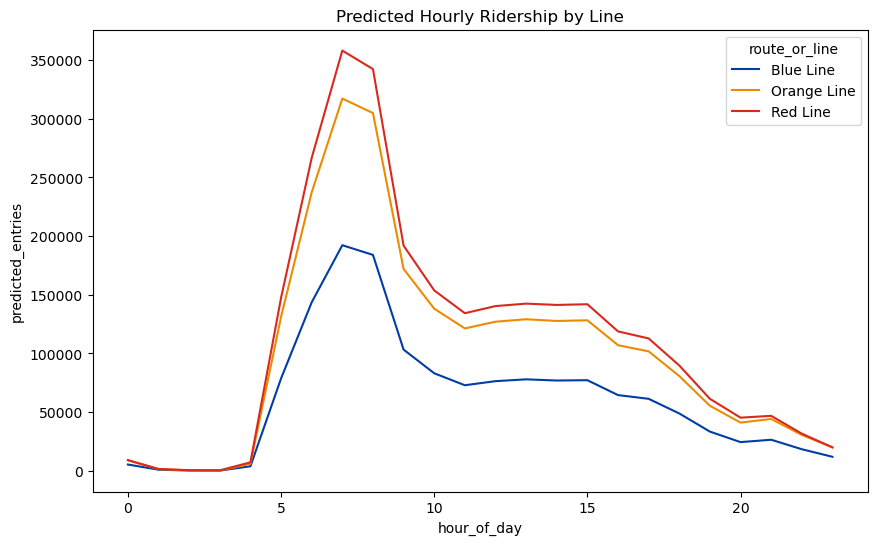

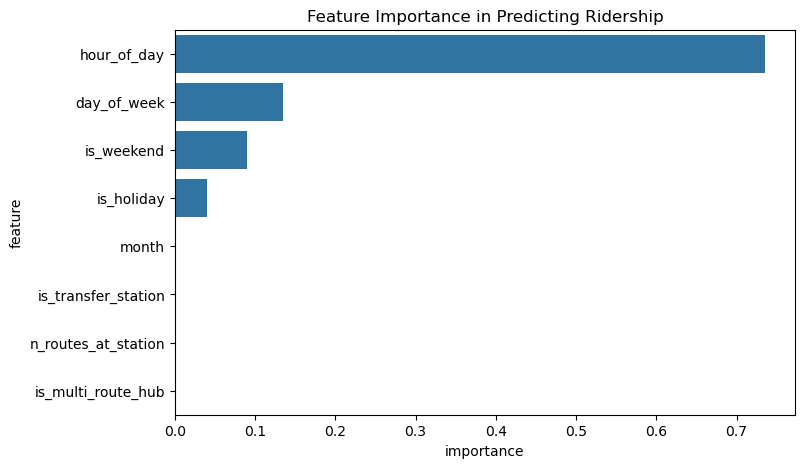

In [ ]:
import numpy as np
import pandas as pd
# Visualize predicted ridership patterns across all routes/lines
plt.figure(figsize=(10,6))
pre_data['predicted_entries'] = model.predict(pre_data[['hour_of_day', 'day_of_week', 'month', 'is_weekend', 'is_holiday','is_transfer_station','n_routes_at_station','is_multi_route_hub']])
pic_data = pre_data.groupby(['hour_of_day', 'route_or_line','route_color'])['predicted_entries'].sum().reset_index()
print(pic_data.head())
sns.lineplot(x='hour_of_day', y='predicted_entries', hue='route_or_line', palette=pic_data.set_index('route_or_line')['route_color'].to_dict(), data=pic_data)
plt.title('Predicted Hourly Ridership by Line')
plt.show()

# Feature importance analysis
importance = model.feature_importances_
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importance
}).sort_values(by='importance', ascending=False)
# Plot feature importance
plt.figure(figsize=(8,5))
sns.barplot(x='importance', y='feature', data=feature_importance)
plt.title('Feature Importance in Predicting Ridership')
plt.show()



c:\Users\HUANG\DownloadApp\Anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\HUANG\DownloadApp\Anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


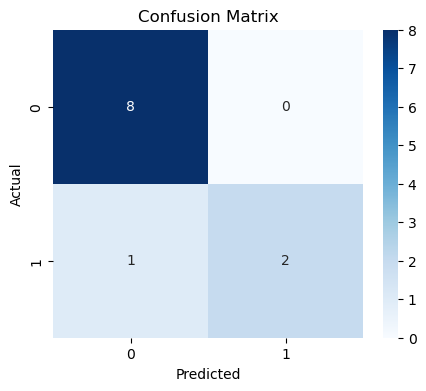

Classification Model Evaluation Metrics:
Accuracy: 0.9091
F1 Score: 0.8000
Precision: 1.0000
Recall: 0.6667


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier

# Aggregate data at the station
station_data = pre_data.copy()
station_data = station_data.groupby('station_name').agg({
    'gated_entries': ['max','min','std'],
    'is_transfer_station': 'max',
    'n_routes_at_station': 'max',
    'is_multi_route_hub': 'max'
    }).reset_index()


# Define features and target
x = station_data[['gated_entries','n_routes_at_station','is_multi_route_hub']]
y = station_data["is_transfer_station"]

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42,stratify=y)

# Define individual model
models = [
    ('Random Forest', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)),
    ('Logistic Regression', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)),
    ('Decision Tree', DecisionTreeClassifier(class_weight='balanced', random_state=42)),
    ('Gradient Boosting', GradientBoostingClassifier(random_state=42))
]
# Create Voting Classifier
voting_model = VotingClassifier(estimators=models, voting='hard')
voting_model.fit(X_train, y_train)

y_pred = voting_model.predict(X_test)

# Confusion Matrix and Classification Report
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Model Report
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
print("Classification Model Evaluation Metrics:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")


